0.6386554621848739
0.5449533125833703
[[11 39]
 [ 4 65]]
              precision    recall  f1-score   support

         0.0       0.73      0.22      0.34        50
         1.0       0.62      0.94      0.75        69

    accuracy                           0.64       119
   macro avg       0.68      0.58      0.54       119
weighted avg       0.67      0.64      0.58       119

0.7478991596638656
0.6497252747252747


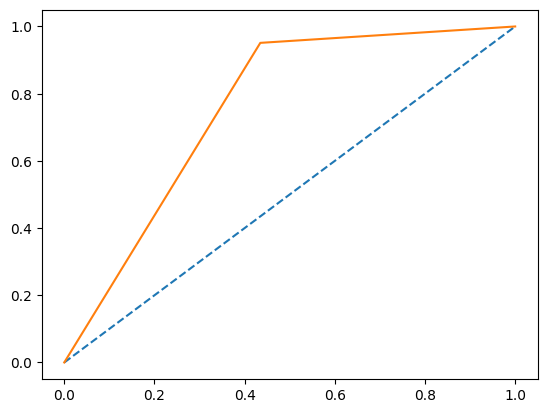

81.25
5ms
0.775438596491228
0.758218451749735


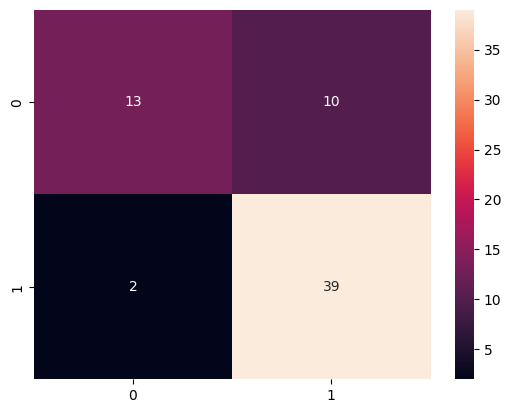

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, roc_curve, accuracy_score, f1_score, roc_auc_score, classification_report

df = pd.read_csv('student-data.csv')
dfv = pd.read_csv('student-data.csv')

def numerical_data():
    df['school'] = df['school'].map({'GP': 0, 'MS': 1})
    df['sex'] = df['sex'].map({'M': 0, 'F': 1})
    df['address'] = df['address'].map({'U': 0, 'R': 1})
    df['famsize'] = df['famsize'].map({'LE3': 0, 'GT3': 1})
    df['Pstatus'] = df['Pstatus'].map({'T': 0, 'A': 1})
    df['Mjob'] = df['Mjob'].map({'teacher': 0, 'health': 1, 'services': 2, 'at_home': 3, 'other': 4})
    df['Fjob'] = df['Fjob'].map({'teacher': 0, 'health': 1, 'services': 2, 'at_home': 3, 'other': 4})
    df['reason'] = df['reason'].map({'home': 0, 'reputation': 1, 'course': 2, 'other': 3})
    df['guardian'] = df['guardian'].map({'mother': 0, 'father': 1, 'other': 2})
    df['schoolsup'] = df['schoolsup'].map({'no': 0, 'yes': 1})
    df['famsup'] = df['famsup'].map({'no': 0, 'yes': 1})
    df['paid'] = df['paid'].map({'no': 0, 'yes': 1})
    df['activities'] = df['activities'].map({'no': 0, 'yes': 1})
    df['nursery'] = df['nursery'].map({'no': 0, 'yes': 1})
    df['higher'] = df['higher'].map({'no': 0, 'yes': 1})
    df['internet'] = df['internet'].map({'no': 0, 'yes': 1})
    df['romantic'] = df['romantic'].map({'no': 0, 'yes': 1})
    df['passed'] = df['passed'].map({'no': 0, 'yes': 1})
    col = df['passed']
    del df['passed']
    df['passed'] = col

def feature_scaling(df):
    for i in df:
        col = df[i]
        if np.max(col) > 6:
            df[i] = (col - np.mean(col)) / np.max(col)
        else:
            df[i] = (col - np.min(col)) / np.max(col)

numerical_data()
feature_scaling(df)

data = df.to_numpy()
n = data.shape[1]
x = data[:, :n-1]
y = data[:, n-1]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

logisticRegr = LogisticRegression(C=1)
logisticRegr.fit(x_train, y_train)
y_pred = logisticRegr.predict(x_test)

print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

y = df.passed
x = df.drop(['passed'], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=71027464)
KNN = KNeighborsClassifier()
KNN.fit(x_train, y_train)
y_pred = KNN.predict(x_test)

print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))

def split(df, rest_size, test_size, randomState):
    data = df.to_numpy()
    n = data.shape[1]
    x = data[:, :n-1]
    y = data[:, n-1]
    X_train, X_rest, y_train, y_rest = train_test_split(x, y, test_size=rest_size, random_state=randomState)
    X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=test_size, random_state=randomState)
    return X_train, X_val, X_test, y_train, y_val, y_test

def showResults(accuracy, trainingTime, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    plt.plot([0,1],[0,1],'--')
    plt.plot(fpr, tpr)
    plt.show()
    print(accuracy)
    print(trainingTime)
    print(f1_score(y_test, y_pred, average='macro'))
    print(roc_auc_score(y_test, y_pred))
    sns.heatmap(cm, annot=True)
    plt.show()

X_train, X_val, X_test, y_train, y_val, y_test = split(df, 0.4, 0.4, 388628375)
clf = SVC(kernel='linear')
t0 = time()
clf.fit(X_train, y_train)
t1 = time()
y_pred = clf.predict(X_test)
showResults(accuracy_score(y_test, y_pred)*100, str(round((t1-t0)*1000))+"ms", y_pred)
